# TP2: FIR delay effect
## Autor: Volodya ALEKSANYAN

**Goal**: implement the echo/delay effect $s[t] = e[t] + \alpha e[t-D]$ with an FIR filter, then get its impulse response and frequency response numerically.

### TO DO: FIR DELAY EFFECT
- Data:
Any (short) sound file
- Goal:
The FIR lter for delay effect can be implement thanks to the following input-output equation ($e[t]$ is the input and $s[t]$ is the output):

$s[t] = e[t] + αe[t − D]$

- Where $α > 0$ is the attenuation factor and $D$ is the time delay
    - Implement the delay effect in the time domain
    - Determine the impulse response of the lter (numerically)
    - Provide the Frequency response of the lter (numerically)

I don't need mathematical proof, just a numerical results. Don't overthing convolutions. We have to choose a fine D. We can test several D values, but can also try to justify the choice of one. 

## 1. Load the sound and choose parameters

We use `music.wav` (16 kHz, ~8.75 s).

**Choice of D**: an echo is heard as a distinct repetition, and it seems to be short. We take $D = 0.25$ s (= 4000 samples at 16 kHz) and $\alpha = 1$. We will test other values of $D$ later.

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from IPython.display import Audio, display

fs, e = wavfile.read('../data/music.wav')
e = e.astype(float) / np.max(np.abs(e)) #norm to -1, 1
t = np.arange(len(e)) / fs

alpha = 1
D_sec = 0.25
D = int(round(D_sec * fs))  # delay
print(f'fs = {fs} Hz, {len(e)} samples, D = {D} samples = {D/fs*1000:.0f} ms, alpha = {alpha}')

fs = 16000 Hz, 140001 samples, D = 4000 samples = 250 ms, alpha = 1


In [43]:
import os

# directory to save audio outputs as .wav files, since the Audio() player doesn't render in VS Code notebooks
AUDIO_OUT_DIR = '../data/outputs/audio'
if not os.path.isdir(AUDIO_OUT_DIR):
    os.makedirs(AUDIO_OUT_DIR)

def save_audio(x, fs, name):
    """Normalise x to [-1, 1], save it as a wav file in AUDIO_OUT_DIR, and return its path."""
    x = x / np.max(np.abs(x))
    path = os.path.join(AUDIO_OUT_DIR, name)
    wavfile.write(path, fs, (x * 32767).astype(np.int16))
    print(f'saved: {path}')
    return path

## 2. Delay effect in the time domain

$s[t] = e[t] + \alpha e[t-D]$, with $e[t-D]=0$ for $t<D$. The output is $D$ samples longer than the input so the echo tail is not cut.

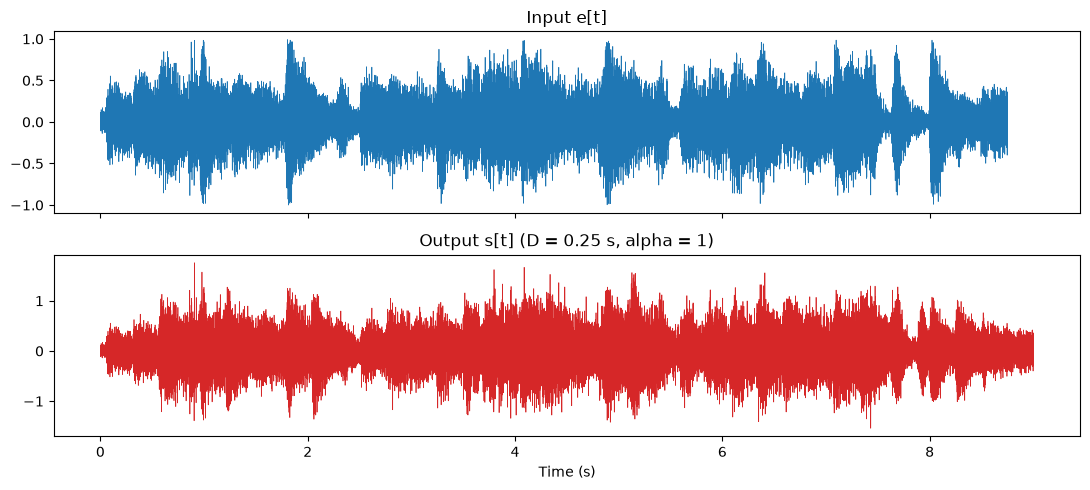

Original:


saved: ../data/outputs/audio/fir_original.wav
With delay:


saved: ../data/outputs/audio/fir_delay.wav


'../data/outputs/audio/fir_delay.wav'

In [44]:
def delay_effect(e, alpha, D):
    lenE = len(e)
    s = np.zeros(D+lenE)
    s[:lenE] += e             # we fill the e[t] part
    s[D: D+lenE] += alpha * e  # fill the alpha * e[t-D] part
    return s

s = delay_effect(e, alpha, D)
ts = np.arange(len(s)) / fs

fig, ax = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
ax[0].plot(t, e, lw=.5); ax[0].set_title('Input e[t]')
ax[1].plot(ts, s, lw=.5, color='tab:red'); ax[1].set_title(f'Output s[t] (D = {D_sec} s, alpha = {alpha})')
ax[1].set_xlabel('Time (s)')
plt.tight_layout(); plt.show()

print('Original:');  display(Audio(e, rate=fs)); save_audio(e, fs, 'fir_original.wav')
print('With delay:'); display(Audio(s / np.max(np.abs(s)), rate=fs)); save_audio(s, fs, 'fir_delay.wav')

## 3a. Impulse response (numerical)

non-zero samples at t = [   0 4000] 
values = [1. 1.]


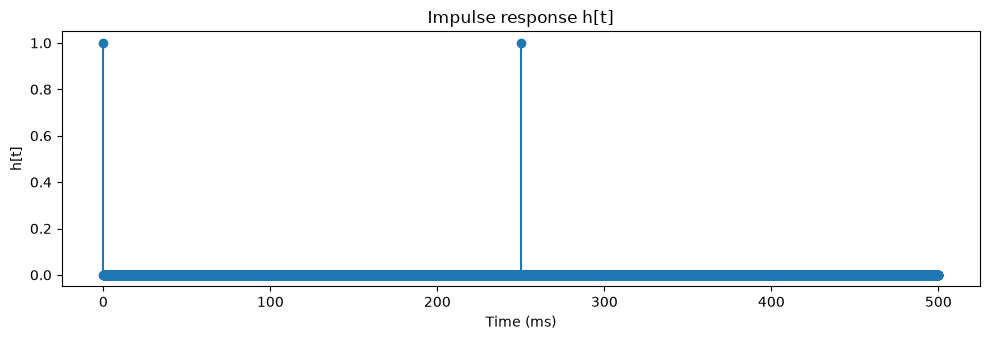

In [45]:
N = 2*D
dirac = np.zeros(N)
dirac[0] = 1

h = delay_effect(dirac, alpha, D)[:N]

nz = np.nonzero(h)[0]
print(f"non-zero samples at t = {nz} \nvalues = {h[nz]}")

plt.figure(figsize=(10, 3.5))
plt.stem(np.arange(N) / fs * 1000, h, basefmt=' ')
plt.xlabel('Time (ms)'); plt.ylabel('h[t]'); plt.title('Impulse response h[t]')
plt.tight_layout(); plt.show()

## 3b. Impulse response (mathematical)
... (i'll do it if I have time)

## 4. Frequency response

$H(f)$ is the DFT of the impulse response. We plot the magnitude (linear and dB) and the phase.

*comb filter*, $|H(f)| = \sqrt{1+\alpha^2+2\alpha\cos(2\pi f D/f_s)}$, with maxima $1+\alpha$ at $f = k f_s/D$ (here $f_s/D = 4$ Hz) and minima $1-\alpha$ in between.

/tmp/ipykernel_69881/1299380944.py:11: RuntimeWarning: divide by zero encountered in log10
  ax[1].plot(f, 20*np.log10(np.abs(H)))


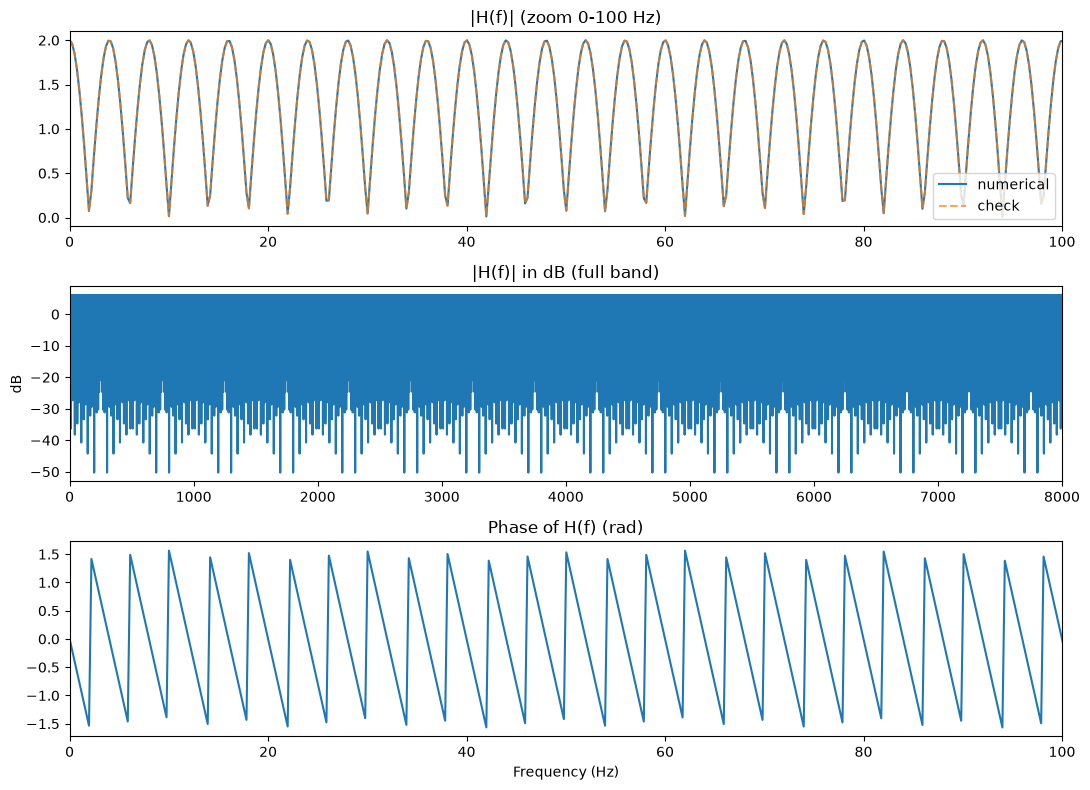

max |H| = 2.0  (1+alpha = 2 )
min |H| = 0.0  (1-alpha = 0 )
peak spacing (Hz) = 4.0


In [46]:
nfft = 2**16
H = np.fft.rfft(h, nfft)
f = np.fft.rfftfreq(nfft, 1/fs)

# theoretical curve only as a check of the numerical result
H_th = np.sqrt(1 + alpha**2 + 2*alpha*np.cos(2*np.pi*f*D/fs))

fig, ax = plt.subplots(3, 1, figsize=(11, 8))
ax[0].plot(f, np.abs(H), label='numerical'); ax[0].plot(f, H_th, '--', label='check', alpha=.7)
ax[0].set_xlim(0, 100); ax[0].set_title('|H(f)| (zoom 0-100 Hz)'); ax[0].legend()
ax[1].plot(f, 20*np.log10(np.abs(H)))
ax[1].set_xlim(0, fs/2); ax[1].set_title('|H(f)| in dB (full band)'); ax[1].set_ylabel('dB')
ax[2].plot(f, np.unwrap(np.angle(H)))
ax[2].set_xlim(0, 100); ax[2].set_title('Phase of H(f) (rad)'); ax[2].set_xlabel('Frequency (Hz)')
plt.tight_layout(); plt.show()

print('max |H| =', np.abs(H).max(), ' (1+alpha =', 1+alpha, ')')
print('min |H| =', np.abs(H).min(), ' (1-alpha =', 1-alpha, ')')
print('peak spacing (Hz) =', fs/D)

## 5. Effect of D

We compare several delays. Small $D$ (a few ms) gives a comb-filtering / metallic colouration (peaks far apart), $D \approx 50$-$100$ ms gives a doubling and larger $D$ gives a clear separate echo. The peak spacing $f_s/D$ shrinks as $D$ grows.

D = 5 ms


saved: ../data/outputs/audio/fir_delay_D5ms.wav
D = 10 ms


saved: ../data/outputs/audio/fir_delay_D10ms.wav
D = 20 ms


saved: ../data/outputs/audio/fir_delay_D20ms.wav
D = 50 ms


saved: ../data/outputs/audio/fir_delay_D50ms.wav
D = 75 ms


saved: ../data/outputs/audio/fir_delay_D75ms.wav
D = 150 ms


saved: ../data/outputs/audio/fir_delay_D150ms.wav
D = 250 ms


saved: ../data/outputs/audio/fir_delay_D250ms.wav
D = 500 ms


saved: ../data/outputs/audio/fir_delay_D500ms.wav


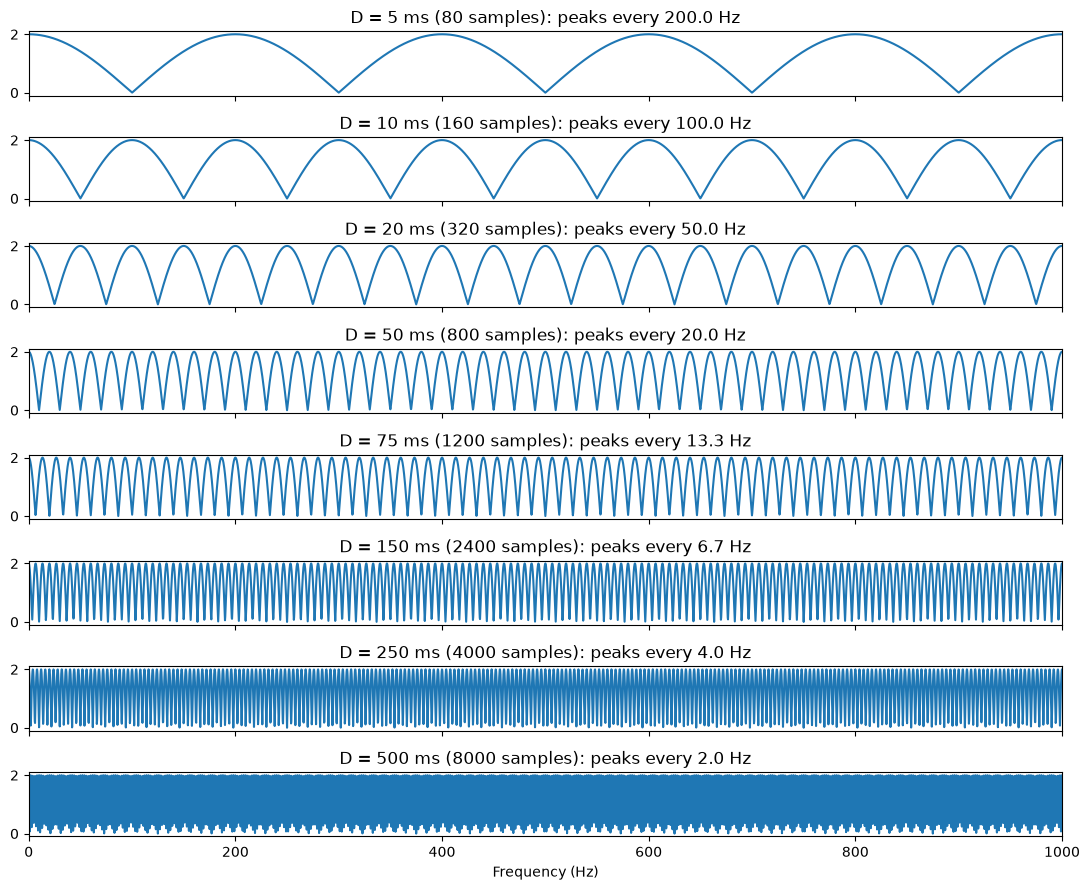

In [47]:
Ds_ms = [5, 10, 20, 50, 75, 150, 250, 500]
fig, ax = plt.subplots(len(Ds_ms), 1, figsize=(11, 9), sharex=True)
for a, d_ms in zip(ax, Ds_ms):
    Dk = int(round(d_ms/1000*fs))
    hk = np.zeros(Dk+1); hk[0] = 1; hk[Dk] = alpha
    Hk = np.fft.rfft(hk, nfft)
    a.plot(f, np.abs(Hk)); a.set_xlim(0, 1000)
    a.set_title(f'D = {d_ms} ms ({Dk} samples): peaks every {fs/Dk:.1f} Hz')
    sk = delay_effect(e, alpha, Dk)
    print(f'D = {d_ms} ms'); display(Audio(sk / np.max(np.abs(sk)), rate=fs)); save_audio(sk, fs, f'fir_delay_D{d_ms}ms.wav')
ax[-1].set_xlabel('Frequency (Hz)')
plt.tight_layout(); plt.show()

## Conclusion

The filter has only two non-zero taps which are $h[0]=1$ and $h[D]=\alpha$. Its frequency response is a Comb filter with gain a between $1-\alpha$ and $1+\alpha$, and peaks spaced by $f_s/D$. To me $D=250$ ms, $\alpha=1$ gives a clear echo. Shorter $D$ does not sound like an echo but just notes that double.